In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

# --- 1. Load Data (Optimized for Streamed I/O and Less Data) ---

try:
    with open('file_list.txt', 'r', encoding='utf-8') as config_file:
        file_names = config_file.read().splitlines()
except FileNotFoundError:
    print("Error: 'file_list.txt' not found. Please ensure it exists.")
    exit()

pattern = re.compile(r'\[(.*?)\] (.*?): (.*)') # Pre-compile regex

datalist = []
stream_count = 0
data_dir = "data\\"

for file in file_names:
    full_path = data_dir + file
    try:
        # Open and read line-by-line to avoid loading the whole file into RAM
        with open(full_path, 'r', encoding='utf-8') as f:
            for line in f:
                match = pattern.match(line)
                if match:
                    date_str, user, _ = match.groups() # Discard 'message' instantly (_)
                    datalist.append([date_str, user, stream_count])
        stream_count += 1
    except FileNotFoundError:
        print(f"Warning: File '{full_path}' not found. Skipping.")
    except Exception as e:
        print(f"Error reading file '{full_path}': {e}")


In [2]:

# --- 2. Create DataFrame and Initial Processing ---

if not datalist:
    print("Error: No data was loaded. Exiting.")
    exit()

# Dropped "message" column completely
data = pd.DataFrame(datalist, columns=["date_str", "user", "stream"])
del datalist # Free up raw list memory immediately

# Convert dates and drop invalid rows
data['date'] = pd.to_datetime(data['date_str'], errors='coerce')
data.drop(columns=['date_str'], inplace=True) # Drop raw string dates to free RAM
data.dropna(subset=['date'], inplace=True)

# Create Period and Month
data['year_month'] = data['date'].dt.to_period('M')
data['month'] = data['date'].dt.month


C:\Users\Kardo\AppData\Local\Temp\ipykernel_19988\3228141586.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['year_month'] = data['date'].dt.to_period('M')


In [3]:

# --- 3. User Replacements / Cleaning ---

replace_map = {
    "Banties1g": "banties_x", "banties1g": "banties_x",
    "chili_poe": "chili_con_bacon", "CHILI_POE": "chili_con_bacon", "chili_conbacon": "chili_con_bacon",
    "Wirelesss_": "W1r3lesss", "treklul": "trek44_", "ttrek_": "trek44_",
    "TriplesingleJ": "TripleSingleJames", "uwu_cougar": "uuccugr", "uuccugr_": "uuccugr",
    "stan_iv4": "StanIV4_", "Muuskie2": "Muuskie", "nishad_more1311": "nishad13",
    "softarballt": "softarr", "softarballtt23": "softarr", "bonkwiththefunk": "bonk67"
}
data["user"] = data["user"].replace(replace_map)

# Capitalization normalization
unique_users = data['user'].unique()
user_variants = defaultdict(set)
for user in unique_users:
    user_variants[user.lower()].add(user)

duplicate_users = {k: v for k, v in user_variants.items() if len(v) > 1}

variant_map = {}
for variants in duplicate_users.values():
    sorted_variants = sorted(variants)
    canonical = sorted_variants[0]
    for v in variants:
        variant_map[v] = canonical

data['user'] = data['user'].apply(lambda u: variant_map.get(u, u))

bots = {'StreamElements', 'Nightbot', 'AnAnonymousGifter', 'Fossabot'} # Switched to set for O(1) lookups
data = data[~data['user'].isin(bots)] # Directly filter main dataframe

# Optimize memory types
data['user'] = data['user'].astype('category') 


In [4]:

# --- 4. Data Aggregation for Plotting ---

first_stream = data.groupby('user', observed=True)['stream'].min().reset_index()
first_stream.columns = ['user', 'first_stream']

data_with_first = pd.merge(data, first_stream, on='user', how='left')

stream_stats = data_with_first.groupby(['stream', 'first_stream'], observed=True)['user'].nunique().reset_index()

try:
    pivot_table = stream_stats.pivot(index='stream', columns='first_stream', values='user').fillna(0)
except Exception as e:
    print(f"Error creating pivot table: {e}")
    exit()

if pivot_table.empty:
    print("Warning: Pivot table is empty. No data to plot.")


In [5]:

# --- 5. Color Generation Logic ---

base_color_map = {
    1: '#008B8B', 2: '#FF8C00', 3: '#006400', 4: '#8B0000', 5: '#450145', 6: '#00008B',
    7: '#808000', 8: "#005F64", 9: '#8B4513', 10: "#5102a1", 11: '#242323', 12: "#9F166D"
}

def generate_shades(base_color, n_shades, lightness_factor=0.7):
    if n_shades <= 0: return []
    try:
        color_rgb = mcolors.to_rgb(base_color)
    except ValueError:
        color_rgb = mcolors.to_rgb('black')

    light_color_rgb = [min(1, max(0, 1 - (1 - c) * (1 - lightness_factor))) for c in color_rgb]
    if n_shades == 1:
        return [mcolors.to_hex(color_rgb)]

    cmap = mcolors.LinearSegmentedColormap.from_list(f'shades_of_{base_color}', [color_rgb, light_color_rgb], N=n_shades)
    return [mcolors.to_hex(cmap(i / (n_shades - 1))) for i in range(n_shades)]

stream_year_months = data.groupby('stream')['year_month'].first()
stream_color_map = {}
unique_year_months = sorted(stream_year_months.dropna().unique())

for ym_period in unique_year_months:
    base_month_num = ym_period.month
    base_color = base_color_map.get(base_month_num, '#808080')

    streams_in_this_period = stream_year_months[stream_year_months == ym_period].index.tolist()
    n_streams_in_period = len(streams_in_this_period)
    shades = generate_shades(base_color, n_streams_in_period)
    
    streams_in_this_period.sort()
    for i, stream_id in enumerate(streams_in_this_period):
        if i < len(shades):
            stream_color_map[stream_id] = shades[i]
        else:
            stream_color_map[stream_id] = base_color

default_color = '#000000'
sorted_color_list = [stream_color_map.get(stream_id, default_color) for stream_id in pivot_table.index]

first_streams_per_month = data.groupby(data['date'].dt.to_period('M'))['stream'].min().tolist()


C:\Users\Kardo\AppData\Local\Temp\ipykernel_19988\3920149052.py:44: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_streams_per_month = data.groupby(data['date'].dt.to_period('M'))['stream'].min().tolist()


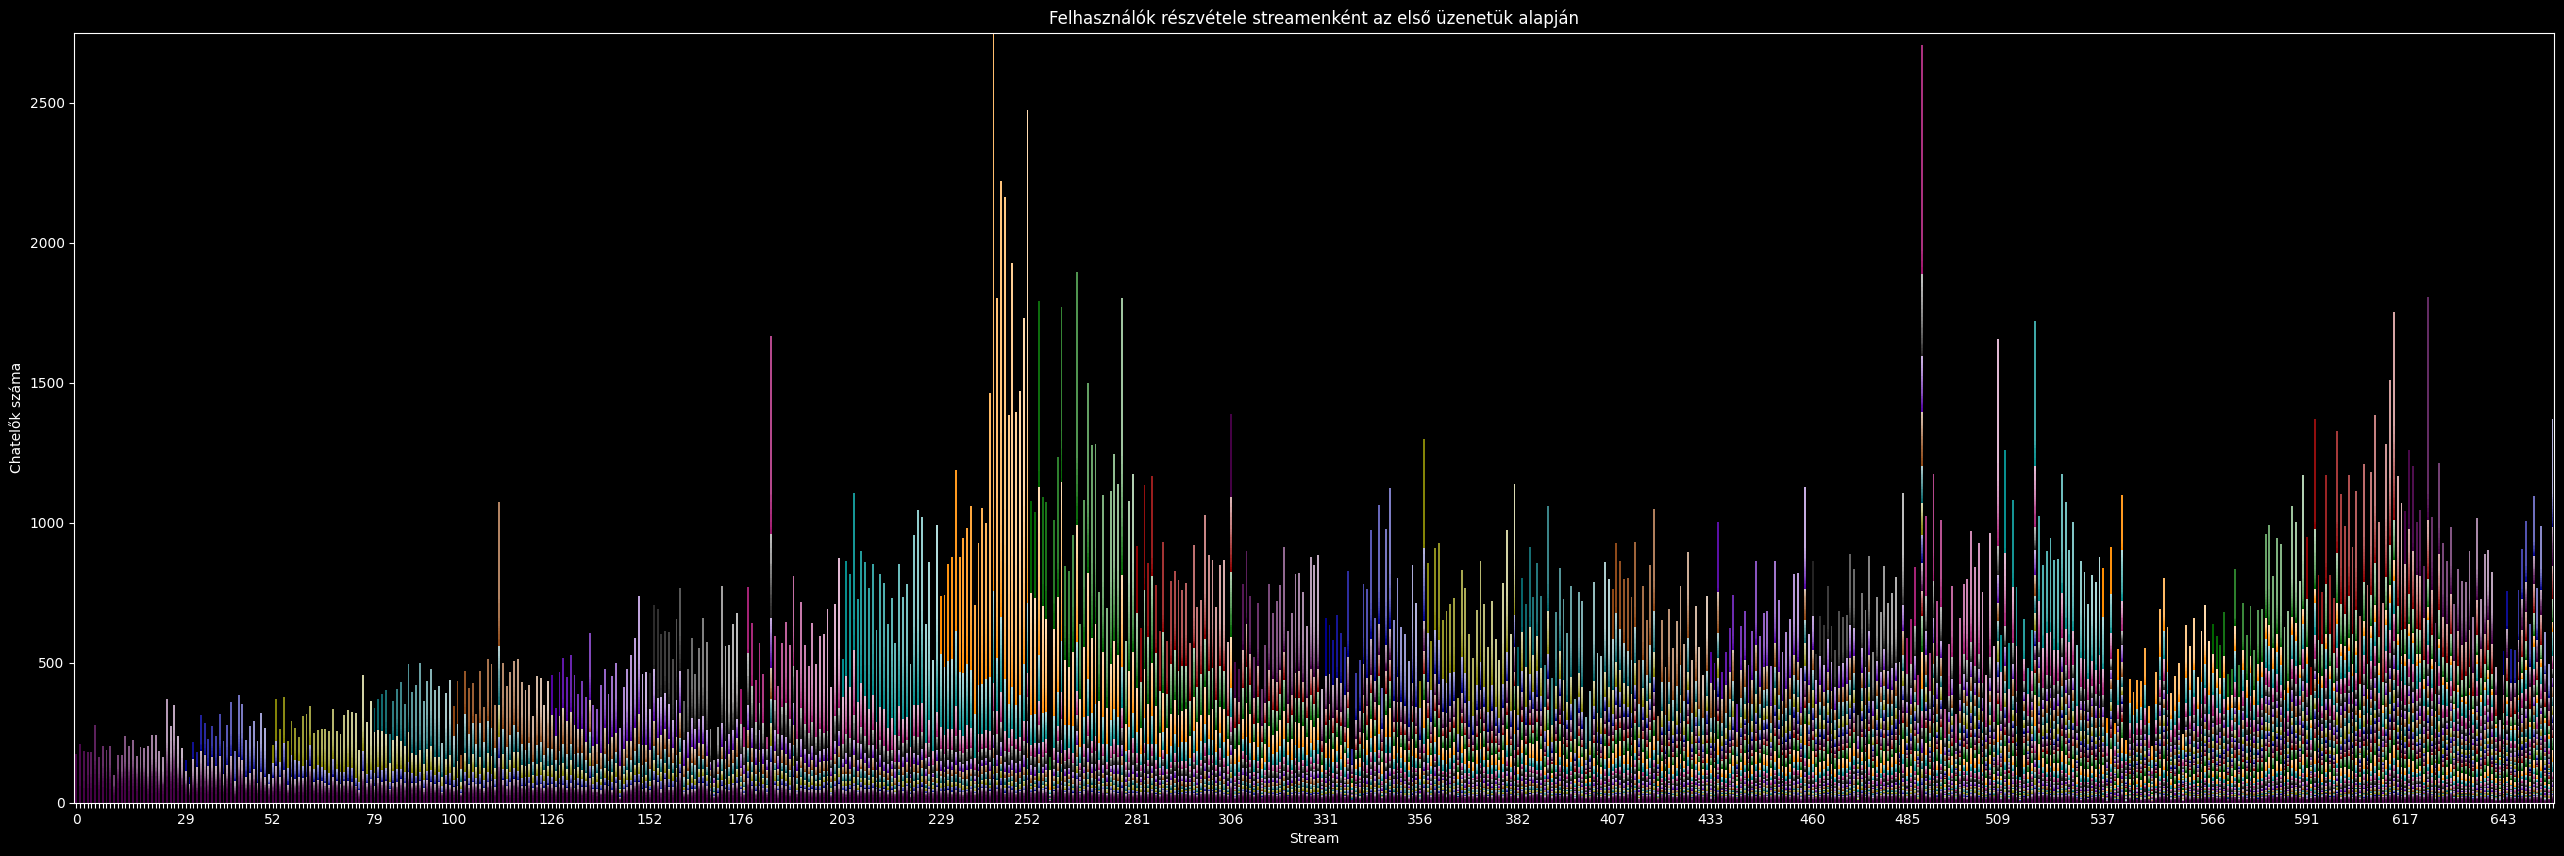

In [6]:


# --- 6. Plotting ---
plt.style.use('dark_background')
ax = pivot_table.plot(kind='bar', stacked=True, figsize=(32, 10), color=sorted_color_list, legend=False)
plt.title('Felhasználók részvétele streamenként az első üzenetük alapján')
plt.xlabel('Stream')
plt.ylabel('Chatelők száma')
plt.ylim(0, 2750)

xticks = range(len(pivot_table.index))
xticklabels = [str(stream_id) if stream_id in first_streams_per_month else "" for stream_id in pivot_table.index]

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0)
plt.show()